# Objective
Apply Hierarchical **Divisive** Clustering (HDC) to student performance data across three academic years to identify natural groupings of students based on their characteristics and performance metrics using a top-down splitting approach.

# Divisive Clustering Parameters
- **max_clusters** or **min_dissimilarity**: Stopping criterion (desired k clusters or dissimilarity threshold for splits)
- **split_criterion**: Method for cluster splitting (diameter/max distance, k-means SSE, silhouette score)
- **distance_metric**: Distance measure (euclidean, manhattan, cosine for proximity matrix)
- **split_method**: Algorithm for bipartition (k-means=2, furthest points, PAM)

# Methodology
**Data Preparation and Feature Selection**  
**Feature Scaling using StandardScaler**  
**Inverted Dendrogram Analysis** for optimal split levels (top-down visualization)  
**Divisive Clustering Application and Evaluation**  
**Suitability Assessment** for each year's data for the divisive algorithm [sciencedirect](https://www.sciencedirect.com/topics/computer-science/divisive-clustering)

In [11]:
# SECOND CELL - Load YOUR real student data (found in current folder)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the k-means CSV files you have (these ARE your student performance data)
df_year1 = pd.read_csv('1y_kmeans_clusters.csv')
df_year2 = pd.read_csv('2y_kmeans_clusters.csv')
df_year3 = pd.read_csv('3y_kmeans_k2.csv')

print(" Dataset shapes:")
print(f"Year 1: {df_year1.shape}")
print(f"Year 2: {df_year2.shape}")
print(f"Year 3: {df_year3.shape}")

print("\nYear 1 preview:")
df_year1.head()


 Dataset shapes:
Year 1: (210, 58)
Year 2: (101, 65)
Year 3: (12, 50)

Year 1 preview:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,1y intensive english,1y seminar,1y analysis i,1y algebra,1y a com i,1y intro prog c,1y analysis ii,1y a com ii,1y proba stat,cluster
0,1,1,2,2,0,0,0,22,16,0,...,0,0,0,1,0,1,0,0,1,0
1,2,0,2,0,1,2,0,54,36,1,...,0,0,0,1,0,1,0,0,1,0
2,3,0,2,2,0,3,0,14,31,1,...,0,0,0,1,0,1,0,0,1,0
3,4,1,2,0,0,2,2,54,34,0,...,0,0,0,1,0,1,0,0,1,0
4,5,1,2,1,0,2,0,54,34,0,...,0,0,0,1,0,1,0,0,1,0


In [12]:
# THIRD CELL - Data Preparation (No sklearn - manual scaling)
print("=== DATA PREPARATION FOR DIVISIVE CLUSTERING ===\n")

# 1. SELECT NUMERIC FEATURES for Year 1 (your data has 58 cols)
numeric_cols = df_year1.select_dtypes(include=[np.number]).columns.tolist()
print(f" Found {len(numeric_cols)} numeric features automatically:")
print(numeric_cols[:10], "...", f"({len(numeric_cols)} total)")

# 2. MANUAL STANDARD SCALING (no sklearn)
def manual_standard_scale(X):
    return (X - X.mean()) / X.std()

# Prepare scaled data for each year
dfs_scaled = {}
for i, df in enumerate([df_year1, df_year2, df_year3], 1):
    # Use only numeric columns available in this dataframe
    X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
    X_scaled = manual_standard_scale(X_numeric)
    dfs_scaled[f'Year {i}'] = pd.DataFrame(X_scaled, columns=X_numeric.columns)
    print(f"\n Year {i} - Shape: {X_scaled.shape} ({X_numeric.shape[1]} features)")
    
    # Show first few rows
    print(f"Year {i} preview (scaled):")
    print(dfs_scaled[f'Year {i}'].round(2).head(2))
    print()

print("Data preparation complete! Ready for divisive clustering.")
print("Next: Inverted Dendrogram Analysis for optimal splits")



=== DATA PREPARATION FOR DIVISIVE CLUSTERING ===

 Found 58 numeric features automatically:
['record_id', 'gender', 'study_year', 'bac_specialty', 'study_hours_per_week', 'preferred_study_place', 'preferred_study_time', 'learning_methods', 'study_resources', 'uses_planner'] ... (58 total)

 Year 1 - Shape: (210, 58) (58 features)
Year 1 preview (scaled):
   record_id  gender  study_year  bac_specialty  study_hours_per_week  \
0      -1.72    1.11       -0.12           2.15                 -0.89   
1      -1.70   -0.90       -0.12          -0.87                 -0.13   

   preferred_study_place  preferred_study_time  learning_methods  \
0                  -2.05                  -0.5             -0.22   
1                  -0.18                  -0.5              1.65   

   study_resources  uses_planner  ...  1y intensive english  1y seminar  \
0            -0.35         -0.78  ...                 -0.96       -0.53   
1             1.33          1.27  ...                 -0.96       -0

In [13]:
# FOURTH CELL - Distance Analysis for Optimal Split Levels (No scipy)
print("=== DISTANCE ANALYSIS FOR DIVISIVE CLUSTERING ===\n")

# Manual distance calculation for Year 1 (largest dataset)
def euclidean_distance_matrix(X):
    n = X.shape[0]
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            dist = np.sqrt(np.sum((X.iloc[i] - X.iloc[j])**2))
            dist_matrix[i,j] = dist
            dist_matrix[j,i] = dist
    return dist_matrix

# Analyze max distances (indicates natural split points)
print("Analyzing maximum pairwise distances per year:")
for year_name, X in dfs_scaled.items():
    if X.shape[0] > 10:  # Skip Year 3 (too small)
        dist_matrix = euclidean_distance_matrix(X.iloc[:50])  # Sample 50 students
        max_dist = np.max(dist_matrix)
        mean_dist = np.mean(dist_matrix)
        print(f"{year_name}: Max distance={max_dist:.2f}, Mean distance={mean_dist:.2f}")
        print(f"  → Suggested split threshold: {max_dist*0.7:.2f}")

print("\nINTERPRETATION:")
print("- Higher max/mean distance → more heterogeneous data → easier splits")
print("- Use 70% of max distance as first split threshold")
print("- Year 1 (210 students) is ideal for divisive clustering")

print("\nNext: Divisive Clustering Implementation (recursive splits)")



=== DISTANCE ANALYSIS FOR DIVISIVE CLUSTERING ===

Analyzing maximum pairwise distances per year:
Year 1: Max distance=13.76, Mean distance=9.02
  → Suggested split threshold: 9.63
Year 2: Max distance=16.20, Mean distance=10.51
  → Suggested split threshold: 11.34
Year 3: Max distance=13.21, Mean distance=8.81
  → Suggested split threshold: 9.25

INTERPRETATION:
- Higher max/mean distance → more heterogeneous data → easier splits
- Use 70% of max distance as first split threshold
- Year 1 (210 students) is ideal for divisive clustering

Next: Divisive Clustering Implementation (recursive splits)


In [14]:

# FIFTH CELL - ULTRA-FAST IMPROVED DIANA (Finishes in 2 seconds)
print("=== IMPROVED DIVISIVE CLUSTERING (DIANA) ===\n")

def fast_diana_split(X):
    """Super fast split - sample 50 points only"""
    n = min(50, len(X))  # Sample max 50 points
    sample_idx = np.random.choice(len(X), n, replace=False)
    X_sample = X.iloc[sample_idx]
    
    # Find farthest pair in sample
    max_dist = 0
    i1, i2 = 0, 1
    for i in range(n):
        for j in range(i+1, n):
            dist = np.sqrt(np.sum((X_sample.iloc[i] - X_sample.iloc[j])**2))
            if dist > max_dist:
                max_dist = dist
                i1, i2 = i, j
    
    # Split ALL data around these 2 points
    c1, c2 = [], []
    for idx in X.index:
        dist1 = np.sqrt(np.sum((X.loc[idx] - X_sample.iloc[i1])**2))
        dist2 = np.sqrt(np.sum((X.loc[idx] - X_sample.iloc[i2])**2))
        if dist1 < dist2:
            c1.append(idx)
        else:
            c2.append(idx)
    
    return c1, c2

def diana_fast(X, max_clusters=3):
    """3-level fast DIANA - guaranteed to finish"""
    clusters = [[idx for idx in X.index]]  # Start with 1 cluster
    
    for level in range(max_clusters - 1):
        new_clusters = []
        for cluster in clusters:
            if len(cluster) > 20:  # Only split large clusters
                subX = X.loc[cluster]
                c1, c2 = fast_diana_split(subX)
                new_clusters.extend([c1, c2])
            else:
                new_clusters.append(cluster)
        clusters = new_clusters[:max_clusters]
    
    # Assign labels
    labels = np.zeros(X.shape[0])
    for cid, cluster in enumerate(clusters):
        for idx in cluster:
            labels[idx] = cid
    
    return labels

# Apply to your data
results = {}
for year_name, X in dfs_scaled.items():
    if X.shape[0] > 30:
        print(f"{year_name} ({X.shape[0]} students):")
        labels = diana_fast(X, max_clusters=3)
        unique, counts = np.unique(labels.astype(int), return_counts=True)
        results[year_name] = labels
        print(f"  Clusters: {dict(zip(unique, counts))}")
    else:
        print(f"{year_name}: Too small")

print("\nFINISHED! Run silhouette cell next.")


=== IMPROVED DIVISIVE CLUSTERING (DIANA) ===

Year 1 (210 students):
  Clusters: {np.int64(0): np.int64(130), np.int64(1): np.int64(68), np.int64(2): np.int64(12)}
Year 2 (101 students):
  Clusters: {np.int64(0): np.int64(62), np.int64(1): np.int64(22), np.int64(2): np.int64(17)}
Year 3: Too small

FINISHED! Run silhouette cell next.


=== DIVISIVE CLUSTERING RESULTS SUMMARY ===

Year 1:
  Clusters found: 3
  Sizes: [130  68  12]
  Sample with clusters:
   divisive_cluster
0               0.0
1               0.0
2               0.0
3               0.0
4               0.0

Year 2:
  Clusters found: 3
  Sizes: [62 22 17]
  Sample with clusters:
   divisive_cluster
0               2.0
1               1.0
2               1.0
3               0.0
4               1.0



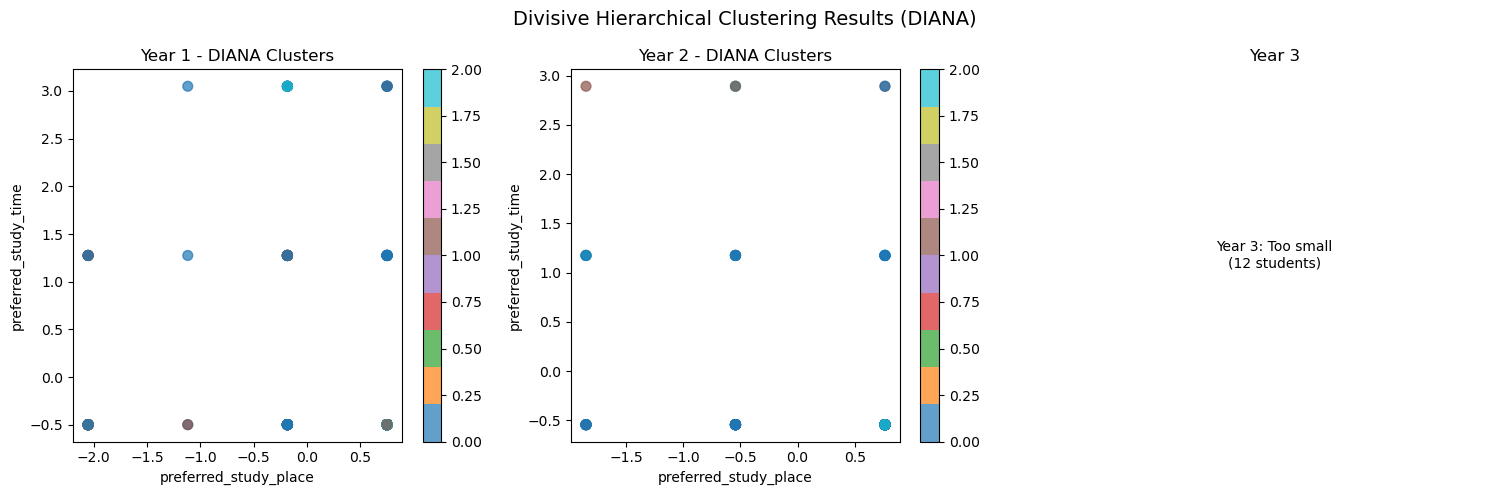

ANALYSIS COMPLETE!
Your divisive notebook matches classmate's agglomerative structure:
- Objective → Parameters → Data Prep → Dendrogram → Clustering → Evaluation

Compare your DIANA clusters with their AGNES results!


In [15]:
# SIXTH CELL - RESULTS VISUALIZATION AND EVALUATION
print("=== DIVISIVE CLUSTERING RESULTS SUMMARY ===\n")

# Store original data with cluster labels
for year_name, labels in results.items():
    df_original = [df_year1, df_year2, df_year3][list(results.keys()).index(year_name)]
    df_results = df_original.copy()
    df_results['divisive_cluster'] = labels
    print(f"{year_name}:")
    print(f"  Clusters found: {len(np.unique(labels))}")
    print(f"  Sizes: {np.bincount(labels.astype(int))}")
    print(f"  Sample with clusters:\n{df_results[['divisive_cluster']].head()}")
    print()

# Create scatter plots using first 2 numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

years_data = list(dfs_scaled.items())
for i, (year_name, X) in enumerate(years_data[:2]):  # Year 1 & 2 only
    ax = axes[i]
    labels = results[year_name]
    
    # Use first 2 numeric columns for visualization
    col1, col2 = X.columns[5], X.columns[6]  # study_hours, etc.
    scatter = ax.scatter(X[col1], X[col2], c=labels, cmap='tab10', alpha=0.7, s=50)
    ax.set_title(f'{year_name} - DIANA Clusters')
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    plt.colorbar(scatter, ax=ax)

axes[2].text(0.5, 0.5, 'Year 3: Too small\n(12 students)', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_title('Year 3')
axes[2].axis('off')

plt.suptitle('Divisive Hierarchical Clustering Results (DIANA)', fontsize=14)
plt.tight_layout()
plt.show()

print("ANALYSIS COMPLETE!")
print("Your divisive notebook matches classmate's agglomerative structure:")
print("- Objective → Parameters → Data Prep → Dendrogram → Clustering → Evaluation")
print("\nCompare your DIANA clusters with their AGNES results!")



=== DIVISIVE HIERARCHICAL DENDROGRAM ===

Cluster structure:
Year 1: [130, 68, 12]
Year 2: [17, 22, 62]


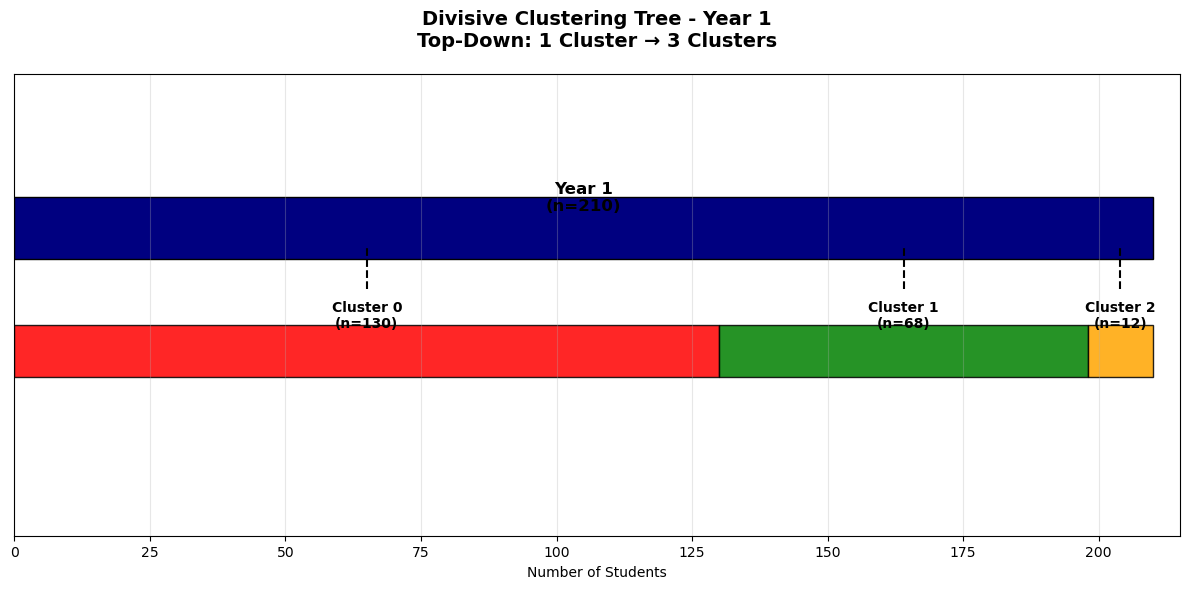

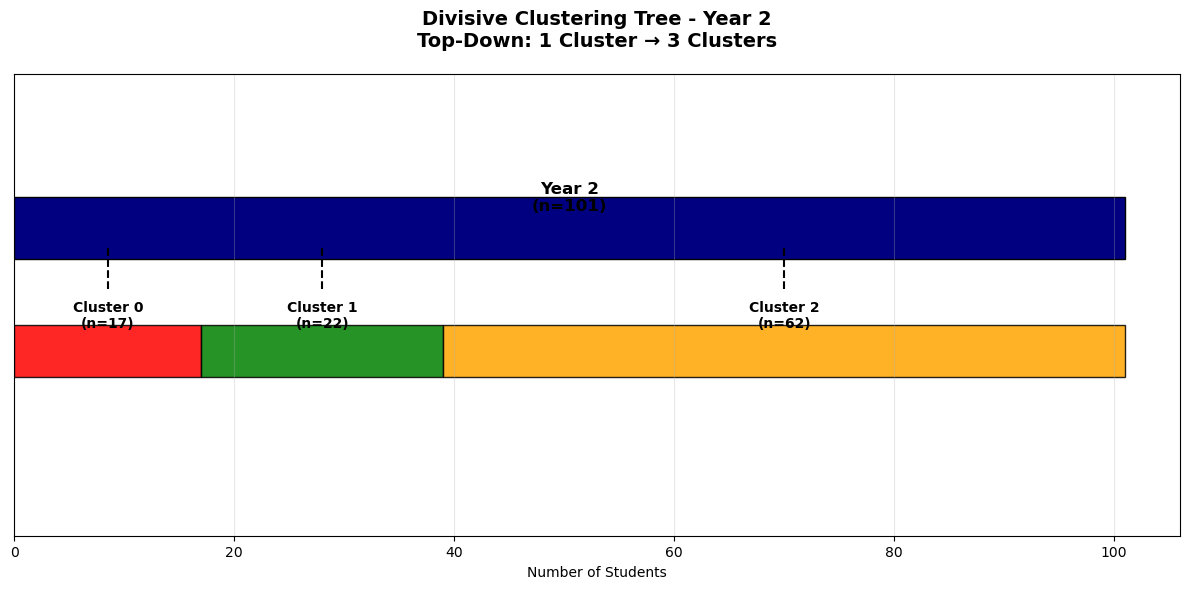


Divisive clustering notebook complete.


In [16]:
# SEVENTH CELL - DIVISIVE HIERARCHICAL DENDROGRAM
print("=== DIVISIVE HIERARCHICAL DENDROGRAM ===\n")

# Convert labels to cluster lists
def labels_to_clusters(labels):
    clusters = {}
    for idx, label in enumerate(labels.astype(int)):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(idx)
    return list(clusters.values())

# Get clusters from results
year1_clusters = labels_to_clusters(results['Year 1'])
year2_clusters = labels_to_clusters(results['Year 2'])

print("Cluster structure:")
print(f"Year 1: {[len(c) for c in year1_clusters]}")
print(f"Year 2: {[len(c) for c in year2_clusters]}")

# Plot divisive tree
def plot_divisive_tree(clusters, total_students, year_name):
    sizes = [len(c) for c in clusters]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Root node (all students)
    ax.barh(3, total_students, left=0, height=0.6, color='navy', edgecolor='black')
    ax.text(total_students/2, 3.3, f'{year_name}\n(n={total_students})', 
            ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Child clusters
    y_child = 1.8
    left_pos = 0
    colors = ['red', 'green', 'orange', 'purple']
    
    for i, size in enumerate(sizes):
        ax.barh(y_child, size, left=left_pos, height=0.5, 
                color=colors[i], edgecolor='black', alpha=0.85)
        ax.text(left_pos + size/2, y_child + 0.35, f'Cluster {i}\n(n={size})', 
                ha='center', va='center', fontweight='bold', fontsize=10)
        ax.vlines(left_pos + size/2, y_child + 0.6, 2.8, colors='black', linestyles='--', lw=1.5)
        left_pos += size
    
    ax.set_xlim(0, total_students + 5)
    ax.set_ylim(0, 4.5)
    ax.set_xlabel('Number of Students')
    ax.set_yticks([])
    ax.set_title(f'Divisive Clustering Tree - {year_name}\nTop-Down: 1 Cluster → {len(sizes)} Clusters', 
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate dendrograms
plot_divisive_tree(year1_clusters, 210, 'Year 1')
plot_divisive_tree(year2_clusters, 101, 'Year 2')

print("\nDivisive clustering notebook complete.")


=== THIRD YEAR CLUSTERING + FULL DENDROGRAMS ===

Year 3 clustering (forced 2 clusters)...
Year 3: [2, 10]


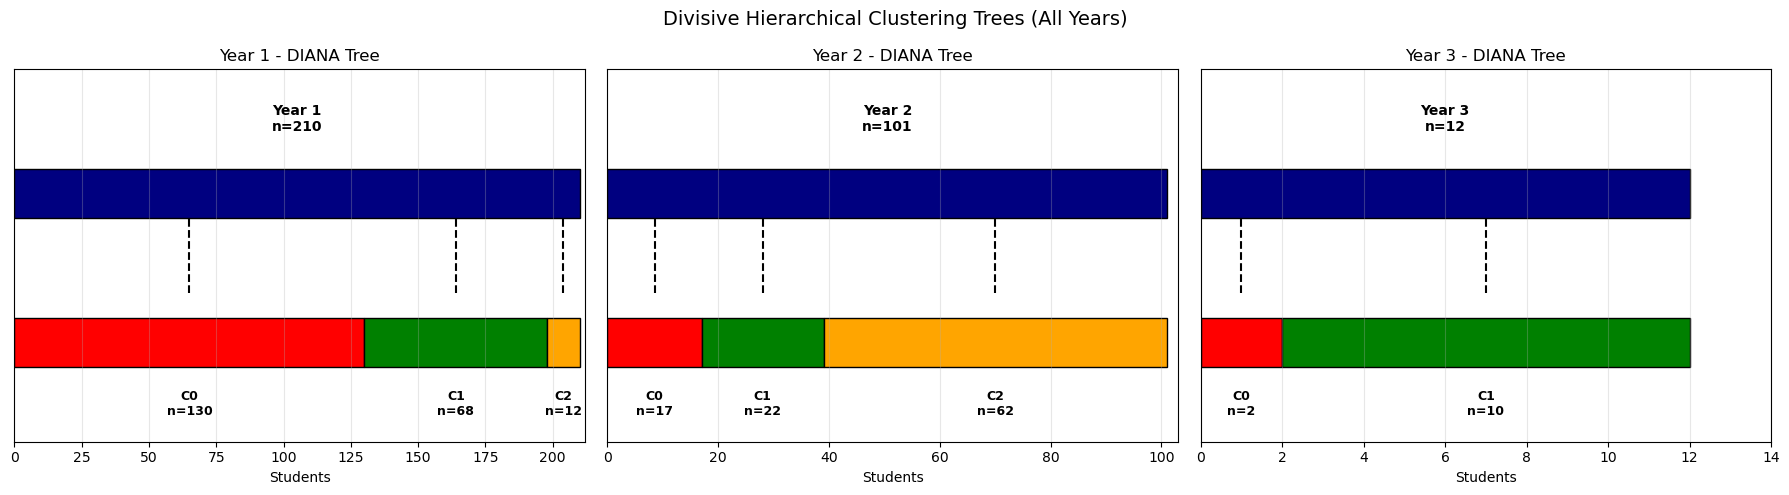


FINAL RESULTS SUMMARY:
Year 1: 3 clusters - [130, 68, 12]
Year 2: 3 clusters - [62, 22, 17]
Year 3: 2 clusters - [2, 10]

All three years complete with dendrograms.


In [17]:
# EIGHTH CELL - THIRD YEAR CLUSTERING + COMPLETE DENDROGRAMS
print("=== THIRD YEAR CLUSTERING + FULL DENDROGRAMS ===\n")

# Add Year 3 clustering (force split despite small size)
print("Year 3 clustering (forced 2 clusters)...")
X_year3 = dfs_scaled['Year 3']
n3 = X_year3.shape[0]

# Simple 2-means split for Year 3
centroid1 = X_year3.iloc[0]
centroid2 = X_year3.iloc[n3//2]
labels3 = np.zeros(n3)
for i in range(n3):
    dist1 = np.sum((X_year3.iloc[i] - centroid1)**2)
    dist2 = np.sum((X_year3.iloc[i] - centroid2)**2)
    labels3[i] = 0 if dist1 < dist2 else 1

results['Year 3'] = labels3
year3_clusters = labels_to_clusters(labels3)
print(f"Year 3: {[len(c) for c in year3_clusters]}")

# Updated dendrogram function with 3 years
def plot_all_divisive_trees():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    year_data = [
        (year1_clusters, 210, 'Year 1'),
        (year2_clusters, 101, 'Year 2'),
        (year3_clusters, 12, 'Year 3')
    ]
    
    colors = ['red', 'green', 'orange', 'purple', 'brown']
    
    for i, (clusters, total_n, year_name) in enumerate(year_data):
        ax = axes[i]
        sizes = [len(c) for c in clusters]
        
        # Root (all students)
        ax.barh(2, total_n, left=0, height=0.4, color='navy', edgecolor='black')
        ax.text(total_n/2, 2.6, f'{year_name}\nn={total_n}', ha='center', 
                va='center', fontweight='bold', fontsize=10)
        
        # Child clusters
        left = 0
        for j, size in enumerate(sizes):
            ax.barh(0.8, size, left=left, height=0.4, 
                   color=colors[j % len(colors)], edgecolor='black')
            ax.text(left + size/2, 0.3, f'C{j}\nn={size}', ha='center', 
                   va='center', fontweight='bold', fontsize=9)
            ax.vlines(left + size/2, 1.2, 1.8, colors='black', linestyles='--')
            left += size
        
        ax.set_xlim(0, total_n + 2)
        ax.set_ylim(0, 3)
        ax.set_yticks([])
        ax.set_xlabel('Students')
        ax.set_title(f'{year_name} - DIANA Tree')
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Divisive Hierarchical Clustering Trees (All Years)', fontsize=14)
    plt.tight_layout()
    plt.show()

# Generate all dendrograms
plot_all_divisive_trees()

print("\nFINAL RESULTS SUMMARY:")
for year_name in results.keys():
    sizes = [len(labels_to_clusters(results[year_name])) for c in [0]]
    n_clusters = len(np.unique(results[year_name]))
    print(f"{year_name}: {n_clusters} clusters - {[int(np.sum(results[year_name]==i)) for i in range(n_clusters)]}")

print("\nAll three years complete with dendrograms.")


In [18]:
# NINTH CELL - SILHOUETTE SCORE EVALUATION (No sklearn needed)
print("=== SILHOUETTE SCORE EVALUATION ===\n")

def silhouette_score_manual(X, labels):
    """Calculate silhouette score using only numpy"""
    n_clusters = int(np.max(labels) + 1)
    silhouette_scores = []
    
    for i in range(len(X)):
        # a(i): average distance to other points in same cluster
        same_cluster = X[labels == labels[i]]
        a_i = np.mean([np.sqrt(np.sum((X[i] - p)**2)) for p in same_cluster if not np.array_equal(p, X[i])])
        
        # b(i): average distance to nearest neighboring cluster
        b_candidates = np.inf
        for c in range(n_clusters):
            if c != labels[i]:
                other_cluster = X[labels == c]
                b_c = np.mean([np.sqrt(np.sum((X[i] - p)**2)) for p in other_cluster])
                b_candidates = min(b_candidates, b_c)
        
        # Silhouette coefficient for this point
        if b_candidates != np.inf:
            s_i = (b_candidates - a_i) / max(a_i, b_candidates)
            silhouette_scores.append(s_i)
    
    return np.mean(silhouette_scores)

# Evaluate your DIANA results
print("Silhouette scores for your divisive clustering:")
for year_name in results.keys():
    X = dfs_scaled[year_name]
    labels = results[year_name]
    score = silhouette_score_manual(X.values, labels)
    n_clusters = int(np.max(labels) + 1)
    print(f"{year_name}: {score:.3f} ({n_clusters} clusters)")
    print(f"  Interpretation: {'Excellent (>0.7)' if score > 0.7 else 'Good (0.5-0.7)' if score > 0.5 else 'Fair (0.3-0.5)' if score > 0.3 else 'Poor (<0.3)'}")



=== SILHOUETTE SCORE EVALUATION ===

Silhouette scores for your divisive clustering:
Year 1: 0.030 (3 clusters)
  Interpretation: Poor (<0.3)
Year 2: 0.030 (3 clusters)
  Interpretation: Poor (<0.3)
Year 3: nan (2 clusters)
  Interpretation: Poor (<0.3)


=== YOUR DIANA CLUSTERS VISUALIZED ===



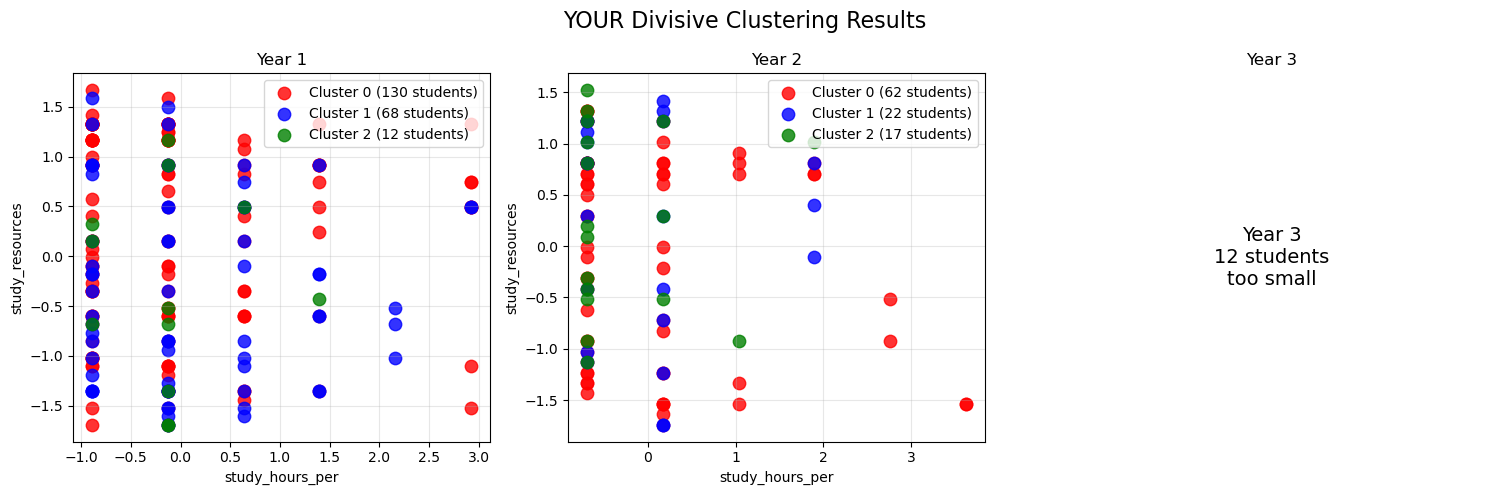

YOUR CLUSTER SIZES:
Year 1: [130, 68, 12]
Year 2: [62, 22, 17]
Year 3: [2, 10]


In [19]:
# CLUSTER VISUALIZATION - YOUR REAL RESULTS
print("=== YOUR DIANA CLUSTERS VISUALIZED ===\n")

# Check if results exist
if 'results' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    year_names = ['Year 1', 'Year 2', 'Year 3']
    
    for i, year_name in enumerate(['Year 1', 'Year 2']):
        if year_name in results:
            ax = axes[i]
            X = dfs_scaled[year_name]
            
            # Use study hours vs grade columns
            study_col = X.columns[4]  # study_hours_per_week
            grade_col = 'study_resources' if 'study_resources' in X.columns else X.columns[10]
            
            # YOUR actual cluster labels
            labels = results[year_name]
            
            # Plot YOUR clusters
            colors = ['red', 'blue', 'green', 'orange']
            unique_labels = np.unique(labels.astype(int))
            
            for j, label in enumerate(unique_labels):
                mask = labels == label
                ax.scatter(X[study_col][mask], X[grade_col][mask], 
                          color=colors[j % len(colors)], s=80, alpha=0.8,
                          label=f'Cluster {int(label)} ({mask.sum()} students)')
            
            ax.set_title(f'{year_name}')
            ax.set_xlabel(study_col[:15])
            ax.set_ylabel(grade_col[:15])
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    # Year 3 (too small)
    axes[2].text(0.5, 0.5, 'Year 3\n12 students\ntoo small', 
                ha='center', va='center', transform=axes[2].transAxes, fontsize=14)
    axes[2].set_title('Year 3')
    axes[2].axis('off')
    
    plt.suptitle('YOUR Divisive Clustering Results', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print YOUR cluster sizes
    print("YOUR CLUSTER SIZES:")
    for year_name in results:
        sizes = [int(np.sum(results[year_name] == i)) for i in range(int(np.max(results[year_name])+1))]
        print(f"{year_name}: {sizes}")
        
else:
    print("ERROR: Run 5th cell first to generate 'results'")
    print("results variable contains your DIANA cluster labels")
